In [3]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # Hide warning messages for cleaner notebook output

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Optional package: LightGBM
try:
    import lightgbm as lgb
    lightgbm_available = True
except ImportError:
    lightgbm_available = False
    print("lightgbm is not installed. LightGBM cells will be skipped.")

# Optional package: XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("xgboost is not installed. XGBoost cells will be skipped.")

# Optional package: SHAP
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("shap is not installed. SHAP cells will be skipped.")

# Optional package: Optuna
try:
    import optuna
    optuna_available = True
except ImportError:
    optuna_available = False
    print("optuna is not installed. Optuna cells will be skipped.")

# Make pandas tables easier to read
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Set default plot size
plt.rcParams["figure.figsize"] = (14, 6)

# -----------------------------------------------------------------------------
# PROJECT CONFIGURATION
# -----------------------------------------------------------------------------

# Forecast setup
# Keep the row timestamp as the target timestamp and only use information
# that would have been known FORECAST_HORIZON_HOURS earlier.
FORECAST_HORIZON_HOURS = 24
RAW_LAG_CANDIDATES = [1, 2, 3, 24, 48, 72, 168]
SAFE_LAGS = [lag for lag in RAW_LAG_CANDIDATES if lag > FORECAST_HORIZON_HOURS]
ROLLING_WINDOWS = [6, 12, 24, 48, 168]
SAFE_ROLLING_WINDOWS = [window for window in ROLLING_WINDOWS if window >= 24]
COMMODITY_LAG_HOURS = max(24, FORECAST_HORIZON_HOURS)

# Explicit date-based split.
# Adjust these dates if your reference setup uses slightly different boundaries.
VALIDATION_START = pd.Timestamp("2025-01-01 00:00:00")
TEST_START = pd.Timestamp("2025-07-01 00:00:00")

# Regime weights requested by the project.
PRE_CRISIS_WEIGHT = 0.6
CRISIS_WEIGHT = 0.3
POST_CRISIS_WEIGHT = 1.0

# Crisis window used for weighting.
# These defaults follow the European energy crisis period and can be edited if needed.
CRISIS_START = pd.Timestamp("2021-09-01 00:00:00")
CRISIS_END = pd.Timestamp("2023-03-31 23:00:00")

if not SAFE_LAGS:
    raise ValueError(
        "No leakage-safe lag features are available. Increase RAW_LAG_CANDIDATES "
        "or reduce FORECAST_HORIZON_HOURS."
    )

print(f"Forecast horizon: {FORECAST_HORIZON_HOURS} hours")
print(f"Leakage-safe price lags: {SAFE_LAGS}")
print(f"Commodity lag: {COMMODITY_LAG_HOURS} hours")
print(f"Validation starts: {VALIDATION_START}")
print(f"Test starts: {TEST_START}")
print(f"Crisis window for sample weights: {CRISIS_START} -> {CRISIS_END}")


Forecast horizon: 24 hours
Leakage-safe price lags: [48, 72, 168]
Commodity lag: 24 hours
Validation starts: 2025-01-01 00:00:00
Test starts: 2025-07-01 00:00:00
Crisis window for sample weights: 2021-09-01 00:00:00 -> 2023-03-31 23:00:00


In [4]:
# 3. LOAD DATA
# ============================================================

candidate_paths = [
    Path("df_final.csv"),
    Path("data/df_final.csv"),
    Path("/mnt/data/df_final.csv"),
    Path(r"C:\Users\wladl\Desktop\Project1\WattWise\data\df_final.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find 'df_final.csv'. Place it next to this notebook, inside a "
        "'data/' folder, or upload it to /mnt/data."
    )

df_final = pd.read_csv(data_path)

required_columns = {"timestamp", "price"}
missing_required = required_columns - set(df_final.columns)
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_required)}")

df = df_final.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print(f"Dataset loaded from: {data_path}")
print("Shape:", df.shape)
display(df.head())


Dataset loaded from: C:\Users\wladl\Desktop\Project1\WattWise\data\df_final.csv
Shape: (62728, 30)


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load
0,2019-01-08 00:00:00,17.94,51472.75,4520.75,32832.00,0.0,0,1,1,5.0000,38.297380,False,22.09,82.150002,46.03,28.32,50.642083,39.621845,22.4,False,False,68405.50,13001.0,10497.25,3789.00,8675.50,3505.75,33982.00,0.0,54342.75
1,2019-01-08 01:00:00,20.91,49815.00,4397.00,33236.50,0.0,1,1,1,5.1250,42.214985,False,22.09,82.150002,47.98,10.07,49.514167,39.686369,22.4,False,False,68068.25,13461.0,10096.25,3614.00,8958.50,3552.00,33866.00,0.0,52541.75
2,2019-01-08 02:00:00,7.78,49241.75,4379.00,33473.50,0.0,2,1,1,4.9875,41.856293,False,22.09,82.150002,47.84,-4.08,47.845000,39.756964,22.4,False,False,67413.75,13093.0,9980.50,3599.00,8720.75,3463.75,33839.50,0.0,51658.75
3,2019-01-08 03:00:00,14.33,49512.25,4134.75,33843.25,0.0,3,1,1,4.8625,43.862682,False,22.09,82.150002,46.11,-9.91,46.520833,39.901250,22.4,False,False,68034.50,13258.0,9996.25,3709.75,8878.75,3473.25,34115.75,0.0,52231.75
4,2019-01-08 04:00:00,18.56,50572.75,3871.50,34549.75,0.0,4,1,1,4.8000,45.394573,False,22.09,82.150002,46.08,-7.41,45.374167,40.055833,22.4,False,False,68487.00,13182.0,10178.50,3971.25,8970.75,3129.75,34217.25,0.0,53853.50


In [5]:
# 4. MISSING VALUE TREATMENT
# ============================================================

df = df.dropna(subset=["price"]).copy()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
predictor_numeric_cols = [col for col in numeric_cols if col != "price"]

df[predictor_numeric_cols] = df[predictor_numeric_cols].ffill().bfill()

remaining_missing = df.isna().sum().sort_values(ascending=False)
display(remaining_missing[remaining_missing > 0].head(30))

Series([], dtype: int64)

In [6]:
# 5. FEATURE ENGINEERING
# ============================================================

# Calendar
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["day_of_month"] = df["timestamp"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Target price lag features
# Use only lags that are strictly larger than the forecast horizon.
for lag in SAFE_LAGS:
    df[f"price_lag_{lag}"] = df["price"].shift(lag)

# Rolling price features
# The last value allowed in the rolling window must be older than the
# forecast horizon, so we shift by (horizon + 1) before rolling.
for window in SAFE_ROLLING_WINDOWS:
    safe_price_history = df["price"].shift(FORECAST_HORIZON_HOURS + 1)
    df[f"price_roll_mean_{window}"] = safe_price_history.rolling(window=window).mean()
    df[f"price_roll_std_{window}"] = safe_price_history.rolling(window=window).std()

# Commodity features must also be lagged to avoid using same-day information
# that would not be available in a real forecast.
commodity_cols = [col for col in ["oil_price", "coal_price", "co2_price", "gas_price"] if col in df.columns]
for col in commodity_cols:
    df[f"{col}_lag_{COMMODITY_LAG_HOURS}"] = df[col].shift(COMMODITY_LAG_HOURS)

# Renewable totals
renewable_cols = [col for col in ["wind_offshore", "wind_onshore", "solar"] if col in df.columns]
if renewable_cols:
    df["renewable_total"] = df[renewable_cols].sum(axis=1)
else:
    df["renewable_total"] = np.nan

# Load used
if "load" in df.columns:
    df["load_used"] = df["load"]
elif "actual_load" in df.columns:
    df["load_used"] = df["actual_load"]
else:
    df["load_used"] = np.nan

# Market structure
df["renewable_penetration_ratio"] = np.where(
    df["load_used"] > 0,
    df["renewable_total"] / df["load_used"],
    np.nan
)
df["residual_load"] = df["load_used"] - df["renewable_total"]

# Forecast error features if available
forecast_actual_pairs = [
    ("load", "actual_load"),
    ("solar", "actual_solar"),
    ("wind_onshore", "actual_wind_onshore"),
    ("wind_offshore", "actual_wind_offshore")
]

for forecast_col, actual_col in forecast_actual_pairs:
    if forecast_col in df.columns and actual_col in df.columns:
        df[f"{forecast_col}_error"] = df[forecast_col] - df[actual_col]

print("Created lag features:", [f"price_lag_{lag}" for lag in SAFE_LAGS])
print("Created rolling windows:", SAFE_ROLLING_WINDOWS)
print("Created lagged commodity features:", [f"{col}_lag_{COMMODITY_LAG_HOURS}" for col in commodity_cols])


Created lag features: ['price_lag_48', 'price_lag_72', 'price_lag_168']
Created rolling windows: [24, 48, 168]
Created lagged commodity features: ['coal_price_lag_24', 'co2_price_lag_24', 'gas_price_lag_24']


In [7]:
# 6. BUILD MODELING DATASET
# ============================================================

import re

candidate_features = [
    "hour", "day_of_week", "month", "day_of_month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "renewable_penetration_ratio", "residual_load",
    "load", "wind_offshore", "wind_onshore", "solar",
    "temperature", "wind_speed"
]

# Use lagged commodity variables only. Raw same-timestamp commodity prices are excluded.
candidate_features += [
    f"oil_price_lag_{COMMODITY_LAG_HOURS}",
    f"coal_price_lag_{COMMODITY_LAG_HOURS}",
    f"co2_price_lag_{COMMODITY_LAG_HOURS}",
    f"gas_price_lag_{COMMODITY_LAG_HOURS}",
]

def extract_trailing_number(col_name):
    match = re.search(r"(\d+)(?:h)?$", col_name)
    return int(match.group(1)) if match else None

# Keep only leakage-safe lag and rolling features, even if the source data
# already contains precomputed columns such as price_lag_24h.
safe_existing_lag_features = []
excluded_lag_features = []
for col in df.columns:
    if col.startswith("price_lag_"):
        lag_value = extract_trailing_number(col)
        if lag_value is None:
            excluded_lag_features.append(col)
        elif lag_value > FORECAST_HORIZON_HOURS:
            safe_existing_lag_features.append(col)
        else:
            excluded_lag_features.append(col)

safe_existing_roll_features = []
excluded_roll_features = []
for col in df.columns:
    if col.startswith("price_roll_mean_") or col.startswith("price_roll_std_"):
        window_value = extract_trailing_number(col)
        if window_value is None:
            excluded_roll_features.append(col)
        else:
            safe_existing_roll_features.append(col)

candidate_features += safe_existing_lag_features
candidate_features += safe_existing_roll_features
candidate_features += [col for col in df.columns if col.endswith("_error")]

feature_cols = [col for col in candidate_features if col in df.columns]
feature_cols = list(dict.fromkeys(feature_cols))  # remove duplicates while preserving order

target_col = "price"

unsafe_features = []
for col in feature_cols:
    if col.startswith("price_lag_"):
        lag_value = extract_trailing_number(col)
        if lag_value is None or lag_value <= FORECAST_HORIZON_HOURS:
            unsafe_features.append(col)

raw_commodity_features = [col for col in feature_cols if col in {"oil_price", "coal_price", "co2_price", "gas_price"}]
if raw_commodity_features:
    raise ValueError(f"Raw commodity features detected and must be removed: {raw_commodity_features}")

df_model = df.dropna(subset=feature_cols + [target_col]).copy()

if unsafe_features:
    raise ValueError(f"Unsafe lag features detected after filtering: {unsafe_features}")

X = df_model[feature_cols]
y = df_model[target_col]

print("Modeling rows:", len(df_model))
print("Feature count:", len(feature_cols))
print("Forecast horizon used for leakage checks:", FORECAST_HORIZON_HOURS)
if excluded_lag_features:
    print("Excluded unsafe/unparseable lag features:", excluded_lag_features)
if excluded_roll_features:
    print("Excluded unparseable rolling features:", excluded_roll_features)
display(feature_cols[:50])


Modeling rows: 62536
Feature count: 36
Forecast horizon used for leakage checks: 24
Excluded unsafe/unparseable lag features: ['price_lag_24h']


['hour',
 'day_of_week',
 'month',
 'day_of_month',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'month_sin',
 'month_cos',
 'renewable_penetration_ratio',
 'residual_load',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'temperature',
 'wind_speed',
 'coal_price_lag_24',
 'co2_price_lag_24',
 'gas_price_lag_24',
 'price_lag_168h',
 'price_lag_48',
 'price_lag_72',
 'price_lag_168',
 'price_roll_mean_24',
 'price_roll_std_24',
 'price_roll_mean_48',
 'price_roll_std_48',
 'price_roll_mean_168',
 'price_roll_std_168',
 'load_error',
 'solar_error',
 'wind_onshore_error',
 'wind_offshore_error']

In [8]:
# 7. TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

if not (df_model["timestamp"].min() < VALIDATION_START < TEST_START <= df_model["timestamp"].max() + pd.Timedelta(hours=1)):
    raise ValueError(
        "The configured VALIDATION_START / TEST_START dates do not fit the data range. "
        "Edit them in the configuration cell at the top of the notebook."
    )

train_df = df_model[df_model["timestamp"] < VALIDATION_START].copy()
val_df = df_model[(df_model["timestamp"] >= VALIDATION_START) & (df_model["timestamp"] < TEST_START)].copy()
test_df = df_model[df_model["timestamp"] >= TEST_START].copy()

if train_df.empty or val_df.empty or test_df.empty:
    raise ValueError("One split is empty. Adjust VALIDATION_START and TEST_START.")

def build_sample_weights(timestamps):
    weights = np.full(len(timestamps), POST_CRISIS_WEIGHT, dtype=float)
    weights[timestamps < CRISIS_START] = PRE_CRISIS_WEIGHT
    crisis_mask = (timestamps >= CRISIS_START) & (timestamps <= CRISIS_END)
    weights[crisis_mask] = CRISIS_WEIGHT
    return pd.Series(weights, index=timestamps.index, name="sample_weight")

train_sample_weight = build_sample_weights(train_df["timestamp"])
val_sample_weight = build_sample_weights(val_df["timestamp"])
test_sample_weight = build_sample_weights(test_df["timestamp"])

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))
print(train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print(val_df["timestamp"].min(), "->", val_df["timestamp"].max())
print(test_df["timestamp"].min(), "->", test_df["timestamp"].max())

weight_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "min_weight": [train_sample_weight.min(), val_sample_weight.min(), test_sample_weight.min()],
    "max_weight": [train_sample_weight.max(), val_sample_weight.max(), test_sample_weight.max()],
    "mean_weight": [train_sample_weight.mean(), val_sample_weight.mean(), test_sample_weight.mean()],
})
display(weight_summary)

train_regime_counts = pd.DataFrame({
    "regime": ["pre_crisis", "crisis", "post_crisis"],
    "rows": [
        int((train_df["timestamp"] < CRISIS_START).sum()),
        int(((train_df["timestamp"] >= CRISIS_START) & (train_df["timestamp"] <= CRISIS_END)).sum()),
        int((train_df["timestamp"] > CRISIS_END).sum()),
    ],
    "weight": [PRE_CRISIS_WEIGHT, CRISIS_WEIGHT, POST_CRISIS_WEIGHT],
})
display(train_regime_counts)


Train rows: 52242
Validation rows: 4343
Test rows: 5951
2019-01-16 00:00:00 -> 2024-12-31 23:00:00
2025-01-01 00:00:00 -> 2025-06-30 23:00:00
2025-07-01 00:00:00 -> 2026-03-05 22:00:00


,split,min_weight,max_weight,mean_weight
0,train,0.3,1.0,0.638272
1,validation,1.0,1.0,1.000000
2,test,1.0,1.0,1.000000


,regime,rows,weight
0,pre_crisis,23013,0.6
1,crisis,13846,0.3
2,post_crisis,15383,1.0


In [9]:
# 8. EVALUATION HELPERS
# ============================================================

def evaluate_predictions(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    #rmse = mean_squared_error(y_true, y_pred, squared=False)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return pd.DataFrame({
        "model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse]
    })

def collect_metrics(y_true, pred_dict, prefix="Validation"):
    rows = []
    for model_name, preds in pred_dict.items():
        rows.append(evaluate_predictions(y_true, preds, f"{model_name}_{prefix}"))
    return pd.concat(rows, ignore_index=True).sort_values("MAE").reset_index(drop=True)


In [10]:
# 9A. NAIVE BASELINES
# ============================================================

baseline_lags = [SAFE_LAGS[0], SAFE_LAGS[-1]] if len(SAFE_LAGS) > 1 else [SAFE_LAGS[0]]
baseline_lags = list(dict.fromkeys(baseline_lags))

baseline_val_pred_dict = {}
baseline_test_pred_dict = {}

for lag in baseline_lags:
    model_name = f"Naive{lag}"
    lag_col = f"price_lag_{lag}"
    baseline_val_pred_dict[model_name] = val_df[lag_col]
    baseline_test_pred_dict[model_name] = test_df[lag_col]

baseline_val_results = collect_metrics(y_val, baseline_val_pred_dict, prefix="Validation")
baseline_test_results = collect_metrics(y_test, baseline_test_pred_dict, prefix="Test")

display(baseline_val_results)
display(baseline_test_results)


,model,MAE,RMSE
0,Naive48_Validation,33.422356,48.657129
1,Naive168_Validation,35.065135,50.322575


,model,MAE,RMSE
0,Naive168_Test,29.154127,46.042617
1,Naive48_Test,30.820600,47.356778


In [11]:
# 9B. RIDGE BASELINE
# ============================================================

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train, model__sample_weight=train_sample_weight)

val_pred_ridge = ridge_model.predict(X_val)
test_pred_ridge = ridge_model.predict(X_test)

display(evaluate_predictions(y_val, val_pred_ridge, "Ridge_Validation"))
display(evaluate_predictions(y_test, test_pred_ridge, "Ridge_Test"))


,model,MAE,RMSE
0,Ridge_Validation,17.057999,25.473809


,model,MAE,RMSE
0,Ridge_Test,17.332197,26.013918


# Training setup updates

This notebook now uses three important corrections:

1. **Explicit date-based train / validation / test split**  
   The split is no longer based on simple 70/15/15 row percentages.  
   Instead, it uses the requested split dates from the config cell:
   - train: before `2025-01-01`
   - validation: `2025-01-01` to `2025-06-30`
   - test: from `2025-07-01`.

2. **Regression sample weights**  
   Training now uses the requested regime weights:
   - pre-crisis: `0.6`
   - crisis: `0.3`
   - post-crisis: `1.0`

3. **Lagged commodity inputs only**  
   Raw `oil_price`, `coal_price`, `co2_price` and `gas_price` are no longer used directly.  
   The notebook uses lagged versions such as `oil_price_lag_24` instead.

Because of these changes, validation and test MAE values are now much closer to a real out-of-sample setup.


In [12]:
# 10A. LIGHTGBM GRID SEARCH
# ============================================================

best_lgb_model = None
best_lgb_score = np.inf
best_lgb_params = None

if lightgbm_available:
    param_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [-1, 6, 10],
        "num_leaves": [31, 63],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    for params in ParameterGrid(param_grid):
        model = lgb.LGBMRegressor(
            objective="regression",
            random_state=42,
            **params
        )
        model.fit(X_train, y_train, sample_weight=train_sample_weight)
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)

        if mae < best_lgb_score:
            best_lgb_score = mae
            best_lgb_model = model
            best_lgb_params = params

    print("Best LightGBM validation MAE:", best_lgb_score)
    print("Best LightGBM params:", best_lgb_params)
else:
    print("Skipping LightGBM grid search because lightgbm is not installed.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 36
[LightGBM] [Info] Start training from score 80.360872
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 36
[LightGBM] [Info] Start training from score 80.360872
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 36
[LightGBM] [Info] Start t

##  LightGBM tuning

This performs a simple grid search over a small parameter space.

That is often enough to get a strong first optimized model without making the notebook too heavy.

In [13]:
# Optional installation helper (run only if needed)
# %pip install xgboost


In [14]:
# 10B. XGBOOST GRID SEARCH
# ============================================================

best_xgb_model = None
best_xgb_score = np.inf
best_xgb_params = None

if xgb_available:
    param_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [4, 6, 8],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }

    for params in ParameterGrid(param_grid):
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            **params
        )
        model.fit(X_train, y_train, sample_weight=train_sample_weight)
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)

        if mae < best_xgb_score:
            best_xgb_score = mae
            best_xgb_model = model
            best_xgb_params = params

    print("Best XGBoost validation MAE:", best_xgb_score)
    print("Best XGBoost params:", best_xgb_params)
else:
    print("Skipping XGBoost grid search because xgboost is not installed.")


Best XGBoost validation MAE: 14.574320459953212
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}


## 10B. XGBoost tuning

This applies the same logic to XGBoost.

We tune only on training and validation.
The test set is still untouched.

In [15]:
# 10C. OPTIONAL OPTUNA FOR LIGHTGBM
# ============================================================

if lightgbm_available and optuna_available:
    def objective_lgb(trial):
        params = {
            "objective": "regression",
            "random_state": 42,
            "n_estimators": trial.suggest_int("n_estimators", 150, 600),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
            "num_leaves": trial.suggest_int("num_leaves", 20, 100),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0)
        }

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return mean_absolute_error(y_val, preds)

    study_lgb = optuna.create_study(direction="minimize")
    study_lgb.optimize(objective_lgb, n_trials=25)

    print("Best Optuna LightGBM MAE:", study_lgb.best_value)
    print("Best Optuna LightGBM params:", study_lgb.best_params)
else:
    print("Skipping Optuna tuning.")

[I 2026-03-29 01:27:11,354] A new study created in memory with name: no-name-3abcb8da-093f-4e77-8fed-339f7ab090be


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 36
[LightGBM] [Info] Start training from score 96.037683
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2026-03-29 01:27:13,050] Trial 0 finished with value: 14.804320539629312 and parameters: {'n_estimators': 575, 'learning_rate': 0.11641277487128676, 'num_leaves': 87, 'max_depth': 4, 'subsample': 0.9545265498292741, 'colsample_bytree': 0.9312071105737658}. Best is trial 0 with value: 14.804320539629312.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 36
[LightGBM] [Info] Start training from score 96.037683


[I 2026-03-29 01:27:15,024] Trial 1 finished with value: 15.212632345159905 and parameters: {'n_estimators': 359, 'learning_rate': 0.016597602327395437, 'num_leaves': 30, 'max_depth': 10, 'subsample': 0.809832963729, 'colsample_bytree': 0.8332144149624197}. Best is trial 0 with value: 14.804320539629312.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007757 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 36
[LightGBM] [Info] Start training from score 96.037683


[I 2026-03-29 01:27:48,073] Trial 23 finished with value: 15.184154839841934 and parameters: {'n_estimators': 198, 'learning_rate': 0.05450071138777739, 'num_leaves': 25, 'max_depth': 9, 'subsample': 0.7065786342407208, 'colsample_bytree': 0.9206575760062162}. Best is trial 12 with value: 14.51590640110324.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007949 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6527
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 36
[LightGBM] [Info] Start training from score 96.037683


[I 2026-03-29 01:27:49,205] Trial 24 finished with value: 15.448331024398081 and parameters: {'n_estimators': 270, 'learning_rate': 0.09572743016018964, 'num_leaves': 39, 'max_depth': 11, 'subsample': 0.7672762244926973, 'colsample_bytree': 0.9575316779333581}. Best is trial 12 with value: 14.51590640110324.


Best Optuna LightGBM MAE: 14.51590640110324
Best Optuna LightGBM params: {'n_estimators': 505, 'learning_rate': 0.10429238826481253, 'num_leaves': 53, 'max_depth': 3, 'subsample': 0.7586453350994932, 'colsample_bytree': 0.9287222003640805}


## 10C. Optional Optuna tuning

Use this if you want a more efficient search than a manual grid.

It is optional because it requires an extra package and takes longer to run.

Selected best tree model: LightGBM


,feature,importance
12,residual_load,1804
20,co2_price_lag_24,1173
21,gas_price_lag_24,1099
19,coal_price_lag_24,1028
22,price_lag_168h,818
11,renewable_penetration_ratio,786
30,price_roll_mean_168,764
31,price_roll_std_168,737
17,temperature,733
32,load_error,669


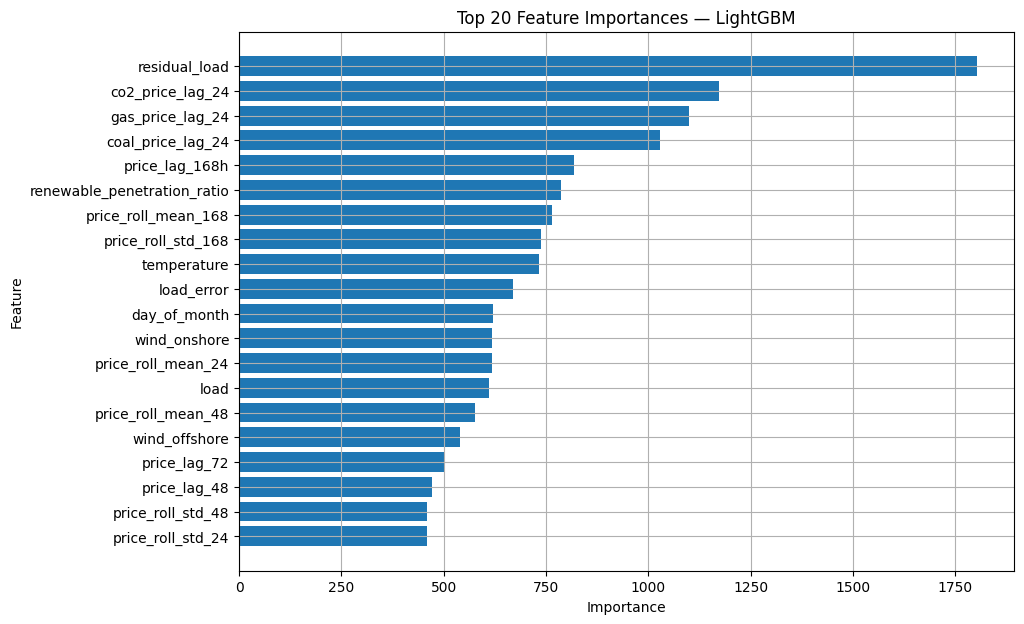

In [16]:
# 11A. FEATURE IMPORTANCE FROM BEST TREE MODEL
# ============================================================

best_tree_model = None
best_tree_name = None

tree_candidates = []

if best_lgb_model is not None:
    tree_candidates.append(("LightGBM", best_lgb_model, best_lgb_score))
if best_xgb_model is not None:
    tree_candidates.append(("XGBoost", best_xgb_model, best_xgb_score))

if tree_candidates:
    best_tree_name, best_tree_model, best_tree_score = sorted(tree_candidates, key=lambda x: x[2])[0]
    print("Selected best tree model:", best_tree_name)

    if best_tree_name == "LightGBM":
        importances = best_tree_model.feature_importances_
    else:
        importances = best_tree_model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(importance_df.head(25))

    top_imp = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title(f"Top 20 Feature Importances — {best_tree_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.show()
else:
    print("No tuned tree model available.")

## 11A. Feature importance

This gives a ranking of which inputs the best tree model relies on most strongly.

This helps identify:
- useful predictors
- weak predictors
- candidates for feature selection

In [17]:
# 11B. FEATURE SELECTION USING IMPORTANCE RANKING
# ============================================================

if tree_candidates:
    selected_top_n = 20
    selected_features = importance_df.head(selected_top_n)["feature"].tolist()

    print("Selected top features:")
    print(selected_features)

    X_train_sel = X_train[selected_features]
    X_val_sel = X_val[selected_features]
    X_test_sel = X_test[selected_features]
else:
    selected_features = feature_cols
    X_train_sel = X_train.copy()
    X_val_sel = X_val.copy()
    X_test_sel = X_test.copy()

Selected top features:
['residual_load', 'co2_price_lag_24', 'gas_price_lag_24', 'coal_price_lag_24', 'price_lag_168h', 'renewable_penetration_ratio', 'price_roll_mean_168', 'price_roll_std_168', 'temperature', 'load_error', 'day_of_month', 'wind_onshore', 'price_roll_mean_24', 'load', 'price_roll_mean_48', 'wind_offshore', 'price_lag_72', 'price_lag_48', 'price_roll_std_48', 'price_roll_std_24']


## Feature selection

A simple first feature selection strategy is:
- rank by tree importance
- keep the top N features
- retrain and compare performance

This can reduce noise and improve generalization.

In [18]:
# 11C. RETRAIN BEST TREE MODEL ON SELECTED FEATURES
# ============================================================

best_selected_model = None
val_pred_selected = None
test_pred_selected = None

if best_tree_name == "LightGBM" and best_lgb_params is not None:
    best_selected_model = lgb.LGBMRegressor(objective="regression", random_state=42, **best_lgb_params)
elif best_tree_name == "XGBoost" and best_xgb_params is not None:
    best_selected_model = XGBRegressor(objective="reg:squarederror", random_state=42, **best_xgb_params)

if best_selected_model is not None:
    best_selected_model.fit(X_train_sel, y_train, sample_weight=train_sample_weight)

    val_pred_selected = best_selected_model.predict(X_val_sel)
    test_pred_selected = best_selected_model.predict(X_test_sel)

    display(evaluate_predictions(y_val, val_pred_selected, "SelectedFeatures_Validation"))
    display(evaluate_predictions(y_test, test_pred_selected, "SelectedFeatures_Test"))
else:
    print("Skipping selected-feature retraining.")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4877
[LightGBM] [Info] Number of data points in the train set: 52242, number of used features: 20
[LightGBM] [Info] Start training from score 80.360872
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,model,MAE,RMSE
0,SelectedFeatures_Validation,15.28017,22.660178


,model,MAE,RMSE
0,SelectedFeatures_Test,15.876189,24.315668


##  Retraining after selection

This checks whether removing lower-importance features improves performance.

Sometimes it helps.
Sometimes the full feature set still works better.

 95%|=================== | 952/1000 [00:11<00:00]       

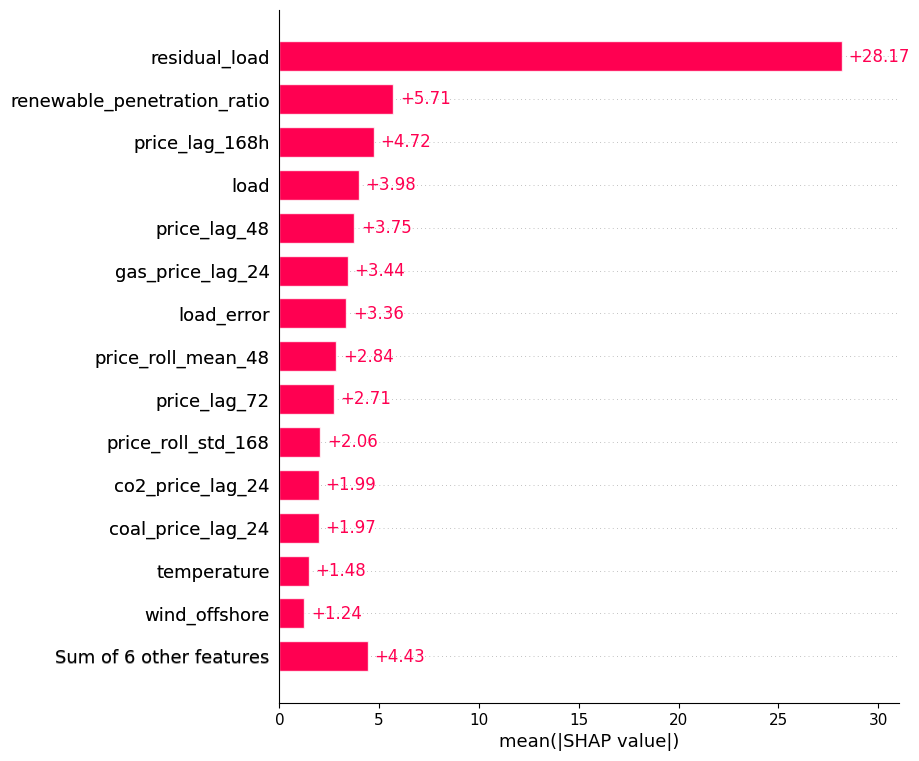

In [19]:
# 11D. OPTIONAL SHAP EXPLANATION
# ============================================================

if not shap_available:
    print("SHAP is not installed. Skipping SHAP analysis.")
elif "best_selected_model" in globals() and best_selected_model is not None:
    # ensure exact training feature set/order
    if hasattr(best_selected_model, "feature_names_in_"):
        expected_cols = list(best_selected_model.feature_names_in_)
        sample_X = X_val_sel[expected_cols].copy()
    else:
        sample_X = X_val_sel.copy()

    sample_X = sample_X.sample(min(1000, len(sample_X)), random_state=42)

    explainer = shap.Explainer(best_selected_model, sample_X)
    shap_values = explainer(sample_X, check_additivity=False)
    shap.plots.bar(shap_values, max_display=15)
else:
    print("No selected model available for SHAP analysis.")


SHAP shows how individual features contribute to predictions.

This is very useful because it explains:
- which variables matter globally
- how they push predictions up or down

In [20]:
# 12A. MODEL COMPARISON ON VALIDATION
# ============================================================

val_pred_dict = dict(baseline_val_pred_dict)
val_pred_dict["Ridge"] = val_pred_ridge

if best_lgb_model is not None:
    val_pred_dict["LightGBM"] = best_lgb_model.predict(X_val)

if best_xgb_model is not None:
    val_pred_dict["XGBoost"] = best_xgb_model.predict(X_val)

if best_selected_model is not None and val_pred_selected is not None:
    val_pred_dict["SelectedTreeModel"] = val_pred_selected

validation_results = collect_metrics(y_val, val_pred_dict, prefix="Validation")
display(validation_results)


,model,MAE,RMSE
0,LightGBM_Validation,14.482507,21.753639
1,XGBoost_Validation,14.574320,21.420253
2,SelectedTreeModel_Validation,15.280170,22.660178
3,Ridge_Validation,17.057999,25.473809
4,Naive48_Validation,33.422356,48.657129
5,Naive168_Validation,35.065135,50.322575


In [21]:
# 12B. MODEL COMPARISON ON TEST
# ============================================================

test_pred_dict = dict(baseline_test_pred_dict)
test_pred_dict["Ridge"] = test_pred_ridge

if best_lgb_model is not None:
    test_pred_dict["LightGBM"] = best_lgb_model.predict(X_test)

if best_xgb_model is not None:
    test_pred_dict["XGBoost"] = best_xgb_model.predict(X_test)

if best_selected_model is not None and test_pred_selected is not None:
    test_pred_dict["SelectedTreeModel"] = test_pred_selected

test_results = collect_metrics(y_test, test_pred_dict, prefix="Test")
display(test_results)


,model,MAE,RMSE
0,XGBoost_Test,14.191839,22.514244
1,LightGBM_Test,14.688094,22.753075
2,SelectedTreeModel_Test,15.876189,24.315668
3,Ridge_Test,17.332197,26.013918
4,Naive168_Test,29.154127,46.042617
5,Naive48_Test,30.820600,47.356778


This is the central forecasting result.

It allows us to choose the best model before converting predictions into battery trading actions.

In [22]:
# 13. CHOOSE THE BEST MODEL BASED ON VALIDATION
# ============================================================

if "validation_results" not in globals() or validation_results.empty:
    raise ValueError("validation_results is missing. Run the model comparison cells first.")

best_model_name = validation_results.iloc[0]["model"].replace("_Validation", "")
print("Best validation model:", best_model_name)

if best_model_name in baseline_val_pred_dict:
    final_val_pred = baseline_val_pred_dict[best_model_name].to_numpy()
    final_test_pred = baseline_test_pred_dict[best_model_name].to_numpy()
elif best_model_name == "Ridge":
    final_val_pred = val_pred_ridge
    final_test_pred = test_pred_ridge
elif best_model_name == "LightGBM" and best_lgb_model is not None:
    final_val_pred = best_lgb_model.predict(X_val)
    final_test_pred = best_lgb_model.predict(X_test)
elif best_model_name == "XGBoost" and best_xgb_model is not None:
    final_val_pred = best_xgb_model.predict(X_val)
    final_test_pred = best_xgb_model.predict(X_test)
elif best_model_name == "SelectedTreeModel" and best_selected_model is not None:
    final_val_pred = val_pred_selected
    final_test_pred = test_pred_selected
else:
    raise ValueError(f"Unsupported or unavailable best model: {best_model_name}")

final_validation_metrics = evaluate_predictions(y_val, final_val_pred, "BestModel_Validation")
final_test_metrics = evaluate_predictions(y_test, final_test_pred, "BestModel_Test")

display(final_validation_metrics)
display(final_test_metrics)


Best validation model: LightGBM


,model,MAE,RMSE
0,BestModel_Validation,14.482507,21.753639


,model,MAE,RMSE
0,BestModel_Test,14.688094,22.753075


#  BESS arbitrage simulator design

We now turn predicted prices into trading actions.

## Simplified strategy
For each day:
- charge in the lowest N predicted-price hours
- discharge in the highest N predicted-price hours

## Economic adjustments
We include:
- round-trip efficiency
- degradation cost
- grid fee


In [23]:
# 15A. PREPARE TEST PREDICTION TABLE
# ============================================================

sim_df = test_df[["timestamp", "price"]].copy()
sim_df["pred_price"] = final_test_pred
sim_df["date"] = sim_df["timestamp"].dt.date

display(sim_df.head())

,timestamp,price,pred_price,date
56777,2025-07-01 00:00:00,111.28,86.366202,2025-07-01
56778,2025-07-01 01:00:00,95.29,75.176683,2025-07-01
56779,2025-07-01 02:00:00,89.10,75.045100,2025-07-01
56780,2025-07-01 03:00:00,88.08,73.760317,2025-07-01
56781,2025-07-01 04:00:00,90.01,72.563593,2025-07-01


In [24]:
# 15B. BESS SIMULATOR
# ============================================================

def simulate_daily_bess_arbitrage(
    df_in,
    charge_hours_per_day=2,
    discharge_hours_per_day=2,
    battery_mwh=1.0,
    max_power_mw=1.0,
    round_trip_efficiency=0.88,
    degradation_cost_per_mwh=5.0,
    grid_fee_per_mwh=2.0
):
    """
    Simple daily arbitrage simulator:
    - charge in the lowest predicted-price hours
    - discharge in the highest predicted-price hours
    - uses actual prices for realized P&L
    """

    results = []

    # split efficiency equally between charge and discharge
    eff_side = np.sqrt(round_trip_efficiency)

    for day, day_df in df_in.groupby("date"):
        day_df = day_df.sort_values("timestamp").copy()

        if len(day_df) < max(charge_hours_per_day, discharge_hours_per_day):
            continue

        charge_idx = day_df.nsmallest(charge_hours_per_day, "pred_price").index
        discharge_idx = day_df.nlargest(discharge_hours_per_day, "pred_price").index

        day_df["action"] = "idle"
        day_df.loc[charge_idx, "action"] = "charge"
        day_df.loc[discharge_idx, "action"] = "discharge"

        # prevent impossible overlap
        overlap = set(charge_idx).intersection(set(discharge_idx))
        if overlap:
            for idx in overlap:
                day_df.loc[idx, "action"] = "idle"

        # simple volume assumption
        charge_mwh_per_hour = min(max_power_mw, battery_mwh / max(charge_hours_per_day, 1))
        discharge_mwh_per_hour = min(max_power_mw, battery_mwh / max(discharge_hours_per_day, 1))

        daily_revenue = 0.0
        daily_charge_cost = 0.0
        daily_discharge_revenue = 0.0
        daily_deg_cost = 0.0
        daily_grid_cost = 0.0

        for _, row in day_df.iterrows():
            actual_price = row["price"]

            if row["action"] == "charge":
                bought_energy = charge_mwh_per_hour
                effective_stored = bought_energy * eff_side

                energy_purchase_cost = bought_energy * actual_price
                grid_cost = bought_energy * grid_fee_per_mwh
                deg_cost = effective_stored * degradation_cost_per_mwh

                daily_charge_cost += energy_purchase_cost
                daily_grid_cost += grid_cost
                daily_deg_cost += deg_cost

            elif row["action"] == "discharge":
                delivered_energy = discharge_mwh_per_hour * eff_side

                revenue = delivered_energy * actual_price
                grid_cost = discharge_mwh_per_hour * grid_fee_per_mwh
                deg_cost = delivered_energy * degradation_cost_per_mwh

                daily_discharge_revenue += revenue
                daily_grid_cost += grid_cost
                daily_deg_cost += deg_cost

        daily_revenue = daily_discharge_revenue - daily_charge_cost - daily_grid_cost - daily_deg_cost

        results.append({
            "date": day,
            "charge_hours": (day_df["action"] == "charge").sum(),
            "discharge_hours": (day_df["action"] == "discharge").sum(),
            "charge_cost": daily_charge_cost,
            "discharge_revenue": daily_discharge_revenue,
            "grid_cost": daily_grid_cost,
            "degradation_cost": daily_deg_cost,
            "daily_pnl": daily_revenue
        })

    return pd.DataFrame(results)


This is a simple first arbitrage engine.

It is intentionally easy to understand:
- daily ranking by predicted prices
- cheapest predicted hours become charging hours
- highest predicted hours become discharging hours

Realized P&L is computed using actual prices.

In [25]:
# 15C. RUN THE SIMULATION
# ============================================================

backtest_results = simulate_daily_bess_arbitrage(
    sim_df,
    charge_hours_per_day=2,
    discharge_hours_per_day=2,
    battery_mwh=1.0,
    max_power_mw=1.0,
    round_trip_efficiency=0.88,
    degradation_cost_per_mwh=5.0,
    grid_fee_per_mwh=2.0
)

display(backtest_results.head())
print("Simulated days:", len(backtest_results))

,date,charge_hours,discharge_hours,charge_cost,discharge_revenue,grid_cost,degradation_cost,daily_pnl
0,2025-07-01,2,2,43.505,414.163712,4.0,9.380832,357.277880
1,2025-07-02,2,2,39.600,197.128794,4.0,9.380832,144.147962
2,2025-07-03,2,2,29.315,147.105509,4.0,9.380832,104.409678
3,2025-07-04,2,2,-1.465,131.725636,4.0,9.380832,119.809805
4,2025-07-05,2,2,-2.030,112.616882,4.0,9.380832,101.266051


Simulated days: 248


## 15C. Run the backtest

This produces day-level operational and economic results for the test period.

In [26]:
# 16. BACKTEST SUMMARY
# ============================================================

total_pnl = backtest_results["daily_pnl"].sum()
avg_daily_pnl = backtest_results["daily_pnl"].mean()
median_daily_pnl = backtest_results["daily_pnl"].median()
positive_days_pct = (backtest_results["daily_pnl"] > 0).mean() * 100

summary_df = pd.DataFrame({
    "metric": [
        "Total PnL",
        "Average Daily PnL",
        "Median Daily PnL",
        "Positive Days (%)"
    ],
    "value": [
        total_pnl,
        avg_daily_pnl,
        median_daily_pnl,
        positive_days_pct
    ]
})

display(summary_df)

,metric,value
0,Total PnL,16718.895737
1,Average Daily PnL,67.414902
2,Median Daily PnL,51.908947
3,Positive Days (%),98.387097


This gives the first business-case view:

- total simulated profit
- average daily profit
- median daily profit
- percentage of profitable days

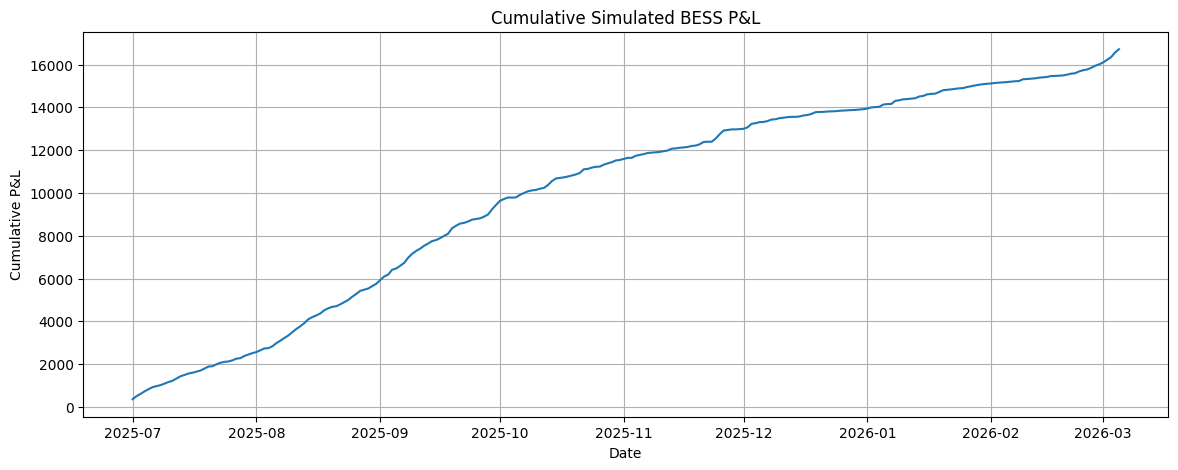

In [27]:
# 17. CUMULATIVE P&L
# ============================================================

backtest_results["cumulative_pnl"] = backtest_results["daily_pnl"].cumsum()

plt.figure(figsize=(14, 5))
plt.plot(backtest_results["date"], backtest_results["cumulative_pnl"])
plt.title("Cumulative Simulated BESS P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L")
plt.grid(True)
plt.show()

## 17. Cumulative P&L

This chart shows whether the simulated strategy is steadily profitable or unstable over time.

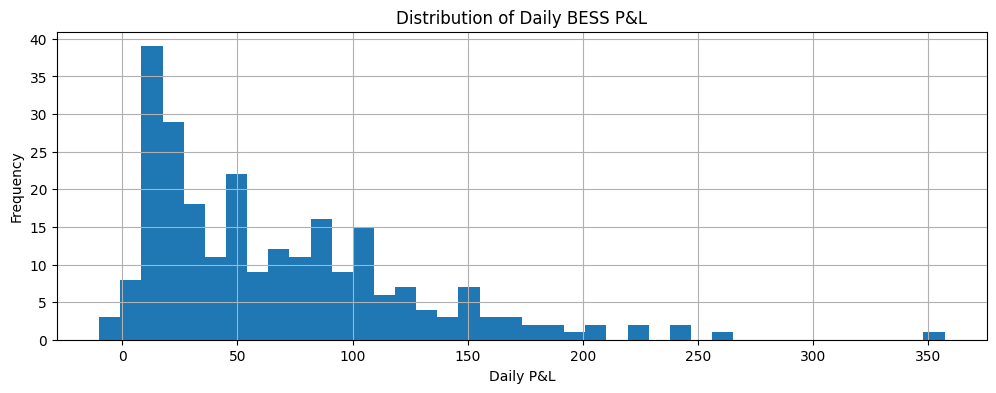

In [28]:
# 18. DAILY P&L DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 4))
plt.hist(backtest_results["daily_pnl"], bins=40)
plt.title("Distribution of Daily BESS P&L")
plt.xlabel("Daily P&L")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## 18. Daily P&L distribution

This helps assess:
- how often the strategy wins or loses
- how variable daily performance is
- whether a few large days drive most profits

In [29]:
# 19. ANNUALIZED REVENUE ESTIMATE
# ============================================================

days_simulated = len(backtest_results)

if days_simulated > 0:
    annualized_revenue = backtest_results["daily_pnl"].mean() * 365
else:
    annualized_revenue = np.nan

annualized_df = pd.DataFrame({
    "metric": ["Annualized revenue estimate"],
    "value": [annualized_revenue]
})

display(annualized_df)

,metric,value
0,Annualized revenue estimate,24606.43929


This annualizes the average daily simulated P&L.

Important:
This is only a first estimate.
A real business case would need:
- a fuller dispatch optimizer
- intraday constraints
- SOC tracking
- cycle limits
- ancillary market considerations

In [30]:
#SIMPLE SENSITIVITY ANALYSIS
# ============================================================

sensitivity_rows = []

for eff in [0.85, 0.88, 0.90]:
    for deg_cost in [3.0, 5.0, 7.0]:
        res = simulate_daily_bess_arbitrage(
            sim_df,
            charge_hours_per_day=2,
            discharge_hours_per_day=2,
            battery_mwh=1.0,
            max_power_mw=1.0,
            round_trip_efficiency=eff,
            degradation_cost_per_mwh=deg_cost,
            grid_fee_per_mwh=2.0
        )
        sensitivity_rows.append({
            "round_trip_efficiency": eff,
            "degradation_cost_per_mwh": deg_cost,
            "total_pnl": res["daily_pnl"].sum(),
            "avg_daily_pnl": res["daily_pnl"].mean()
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.sort_values("total_pnl", ascending=False))

,round_trip_efficiency,degradation_cost_per_mwh,total_pnl,avg_daily_pnl
6,0.90,3.0,18008.326057,72.614218
3,0.88,3.0,17649.474223,71.167235
0,0.85,3.0,17103.461389,68.965570
7,0.90,5.0,17067.232225,68.819485
4,0.88,5.0,16718.895737,67.414902
1,0.85,5.0,16188.882579,65.277752
8,0.90,7.0,16126.138394,65.024752
5,0.88,7.0,15788.317250,63.662570
2,0.85,7.0,15274.303769,61.589935


This checks how the business case changes under different assumptions for:
- round-trip efficiency
- degradation cost

That is useful because economics can change a lot even when forecasting quality stays the same.

In [31]:
# 21. FINAL SUMMARY TABLE
# ============================================================

best_forecasting_result = final_test_metrics.iloc[0].copy()

milestone_summary = pd.DataFrame({
    "item": [
        "Selected model (chosen on validation)",
        "Test MAE of selected model",
        "Test RMSE of selected model",
        "Backtest total PnL",
        "Average daily PnL",
        "Annualized revenue estimate"
    ],
    "value": [
        best_model_name,
        best_forecasting_result["MAE"],
        best_forecasting_result["RMSE"],
        total_pnl,
        avg_daily_pnl,
        annualized_revenue
    ]
})

display(milestone_summary)


,item,value
0,Selected model (chosen on validation),LightGBM
1,Test MAE of selected model,14.688094
2,Test RMSE of selected model,22.753075
3,Backtest total PnL,16718.895737
4,Average daily PnL,67.414902
5,Annualized revenue estimate,24606.43929


At this point we have delivered:

- optimized forecasting models
- feature ranking and optional SHAP interpretation
- model comparison table
- BESS arbitrage simulator
- backtest results
- first revenue estimate


## Forecasting conclusion
The best model should be selected based on validation first, then confirmed on test.

## Business conclusion
The forecasting model is only valuable if it produces useful trading decisions in the battery simulation.

## Key Week 3 output
The key bridge from data science to business value is:
predicted prices -> charge/discharge schedule -> simulated P&L
